
#Notebooks familiarisation project

A basic project using AI generated data on CSV files to refresh my memory of using notebooks for data engineering/analysis

In [ ]:
#Import packages
import numpy as n
import matplotlib.pyplot as plt
import pandas as pd
import pandasql as psql

In [1]:
# Basic calculation example
a = 5
b = 3
result = a + b
print('The sum of', a, 'and', b, 'is', result)

The sum of 5 and 3 is 8


## How to run cells
To run a cell, select it and click the 'Run' button or press Shift+Enter.

In [21]:
# Create DataFrames from the CSVs
customers_df = pd.read_csv('customers.csv')
orders_df = pd.read_csv('orders.csv')
products_df = pd.read_csv('products.csv')

#Display the first few rows of each DataFrame
print("Customers:")
display(customers_df.head())
print("Orders:")
display(orders_df.head())
print("Products:")
display(products_df.head())

Customers:


,customer_id,first_name,last_name,email,city,country,signup_date,age
0,1,David,Johnson,david.johnson1@example.com,Leeds,UK,2018-04-13,32
1,2,John,Johnson,john.johnson2@example.com,Manchester,UK,2024-02-12,20
2,3,James,Johnson,james.johnson3@example.com,Glasgow,UK,2020-06-14,53
3,4,Patricia,Hernandez,patricia.hernandez4@example.com,Bristol,UK,2024-02-11,46
4,5,Elizabeth,Jones,elizabeth.jones5@example.com,Birmingham,UK,2018-01-27,39


Orders:


,order_id,customer_id,product_id,order_date,quantity,unit_price,total_amount,order_status,payment_method
0,1,432,540,2022-02-26,1,178.48,178.48,Pending,Credit Card
1,2,872,18,2021-04-26,3,10.83,32.49,Cancelled,Google Pay
2,3,62,934,2022-08-28,2,277.06,554.12,Cancelled,PayPal
3,4,148,856,2024-10-04,2,95.46,190.92,Returned,Debit Card
4,5,142,121,2021-03-07,2,26.20,52.40,Pending,Apple Pay


Products:


,product_id,product_name,category,price,cost,stock_quantity,supplier
0,1,Coffee Maker,Electronics,25.12,10.76,483,Supplier_14
1,2,Gaming Mouse,Home,480.49,210.86,272,Supplier_25
2,3,Yoga Mat,Clothing,98.78,60.30,320,Supplier_12
3,4,Gaming Mouse,Electronics,281.42,175.40,392,Supplier_41
4,5,Gaming Mouse,Beauty,290.40,194.51,218,Supplier_7


There are a total of 99 customers in Glasgow


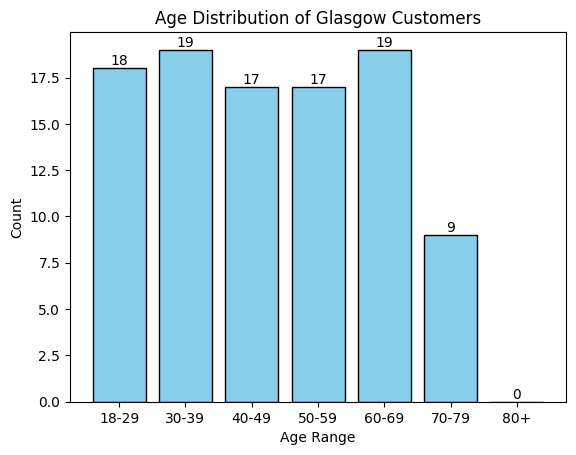

In [75]:
# Generate a DataFrame and age distribution graph for each city's customers
cities = customers_df['city'].unique()
bins = [18, 30, 40, 50, 60, 70, 80, 100]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

city_customers_dfs = {}

for city in cities:
    city_customers = customers_df[customers_df['city'] == city] # Using boolean indexing instead of SQL query for better performance
    city_customers_dfs[city] = city_customers

city = "Glasgow" # Change this to the city you want to analyze
city_customers = city_customers_dfs[city]
#Alternatively, us a for loop to display the age distribution for each city
print(f"There are a total of {len(city_customers)} customers in {city}")
if not city_customers.empty:
    city_customers['age_group'] = pd.cut(city_customers['age'], bins=bins, labels=labels, right=False)
    age_counts = city_customers['age_group'].value_counts().sort_index()
    plt.bar(age_counts.index, age_counts.values, color='skyblue', edgecolor='black')
    plt.title(f'Age Distribution of {city} Customers')
    plt.xlabel('Age Range')
    plt.ylabel('Count')
    for i, v in enumerate(age_counts.values):
        plt.text(i, v, int(v), ha='center', va='bottom')
    plt.show()
else:
    print(f'No customers found for {city}.')
